# 🛠️ Preparación de los Datos

## **1. Extracción del Archivo Tratado**

In [1]:
import pandas as pd

# Ruta del archivo limpio
ruta_archivo = "/content/TelecomX_LATAM.csv"

# Cargar el CSV
df = pd.read_csv(ruta_archivo)

In [3]:
df.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cuentas_Diarias,Churn_binario
0,0002-ORFBO,No,Female,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19,0
1,0003-MKNFE,No,Male,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00,0
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,Yes,Male,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27,1
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   int64  
 5   Dependents        7032 non-null   int64  
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   int64  
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 


## **2. Eliminación de Columnas Irrelevantes**

In [5]:
# Eliminar columnas irrelevantes
columnas_a_eliminar = ['customerID']
df = df.drop(columns=columnas_a_eliminar)

# Verificar que se eliminó
print("Columnas restantes:")
print(df.columns)

Columnas restantes:
Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Cuentas_Diarias', 'Churn_binario'],
      dtype='object')


## **3. Encoding**

In [7]:
# Separar target y features
# Target: Churn_binario (ya la tienes)
y = df['Churn_binario']

# Features: eliminar Churn y Churn_binario para no incluirlas en encoding
X = df.drop(columns=['Churn', 'Churn_binario'])

In [8]:
# Identificar variables categóricas
categoricas = X.select_dtypes(include='object').columns.tolist()
print("Variables categóricas a codificar:", categoricas)

Variables categóricas a codificar: ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [9]:
# Aplicar One-Hot Encoding
# One-Hot Encoding con get_dummies
X_encoded = pd.get_dummies(X, columns=categoricas, drop_first=True)

# Verificar el resultado
print("Shape antes:", X.shape)
print("Shape después del encoding:", X_encoded.shape)
X_encoded.head()

Shape antes: (7032, 20)
Shape después del encoding: (7032, 24)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Cuentas_Diarias,gender_Male,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,1,9,1,1,65.6,593.30,2.19,False,...,True,False,True,True,False,True,False,False,False,True
1,0,0,0,9,1,0,59.9,542.40,2.00,True,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,4,1,1,73.9,280.85,2.46,True,...,False,True,False,False,False,False,False,False,True,False
3,1,1,0,13,1,1,98.0,1237.85,3.27,True,...,True,True,False,True,True,False,False,False,True,False
4,1,1,0,3,1,1,83.9,267.40,2.80,False,...,False,False,True,True,False,False,False,False,False,True


## **4. Verificación de la Proporción de Cancelación (Churn)**

In [10]:
# Conteo de clientes activos y cancelados
conteo = df['Churn_binario'].value_counts()
print("Conteo de clases:\n", conteo)

Conteo de clases:
 Churn_binario
0    5163
1    1869
Name: count, dtype: int64


In [11]:
# Proporción
proporcion = df['Churn_binario'].value_counts(normalize=True)
print("\nProporción de cada clase:\n", proporcion)


Proporción de cada clase:
 Churn_binario
0    0.734215
1    0.265785
Name: proportion, dtype: float64


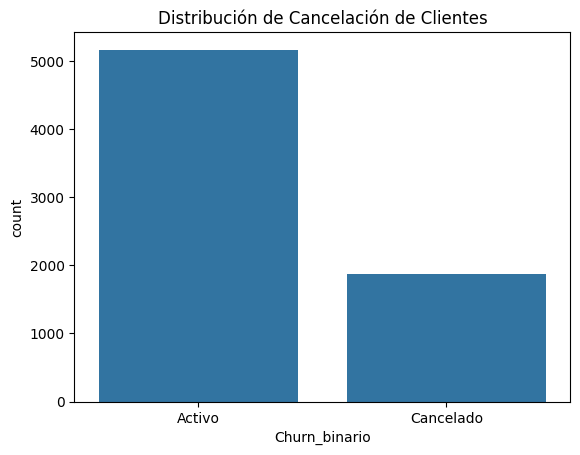

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn_binario', data=df)
plt.xticks([0,1], ['Activo', 'Cancelado'])
plt.title("Distribución de Cancelación de Clientes")
plt.show()

## **5. Balanceo de Clases (opcional)**

In [20]:
# Instalación de SMOTE
!pip install -q imbalanced-learn

In [21]:
# Aplicar SMOTE para balancear clases
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Dividir primero en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicar SMOTE solo en el set de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Verificar el balance
import pandas as pd
print("Distribución original en entrenamiento:\n", y_train.value_counts())
print("\nDistribución después de SMOTE:\n", pd.Series(y_train_bal).value_counts())

Distribución original en entrenamiento:
 Churn_binario
0    3614
1    1308
Name: count, dtype: int64

Distribución después de SMOTE:
 Churn_binario
1    3614
0    3614
Name: count, dtype: int64


## **6. Normalización o Estandarización (si es necesario)**

In [22]:
from sklearn.preprocessing import StandardScaler

# Escalar las features
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)  # aplicamos la misma transformación al test set

# Verificar
print("Ejemplo de features estandarizadas (primeras 5 filas):")
print(X_train_bal_scaled[:5])

Ejemplo de features estandarizadas (primeras 5 filas):
[[-0.39580938  1.28852128  1.88915328 -0.44280119  0.34905251  0.81597893
   0.856907   -0.24164451  0.85152672  0.8687893   1.03062935  0.92376043
  -0.45483984 -0.63242491 -0.75765547 -0.78941459 -0.63800228  1.11410965
   1.09283697 -0.48381699 -0.47289849 -0.52011735  1.04095993 -0.56584684]
 [-0.39580938  1.28852128 -0.52933767  0.88356663  0.34905251  0.81597893
  -1.67174828 -0.51109152 -1.66986331 -1.15102706 -0.97028092 -1.08253175
   2.1985761  -0.63242491 -0.75765547 -0.78941459 -0.63800228 -0.89757772
  -0.91504957  2.06689724 -0.47289849 -0.52011735 -0.96065177 -0.56584684]
 [-0.39580938 -0.77608342 -0.52933767 -0.85729113  0.34905251 -1.22552184
  -1.66128488 -0.86269256 -1.65940111 -1.15102706 -0.97028092 -1.08253175
   2.1985761  -0.63242491 -0.75765547 -0.78941459 -0.63800228 -0.89757772
  -0.91504957 -0.48381699 -0.47289849 -0.52011735 -0.96065177  1.76726267]
 [ 2.52646867 -0.77608342 -0.52933767  1.0908116   0.3

# 🎯 Correlación y Selección de Variables

## **1. Análisis de Correlación**

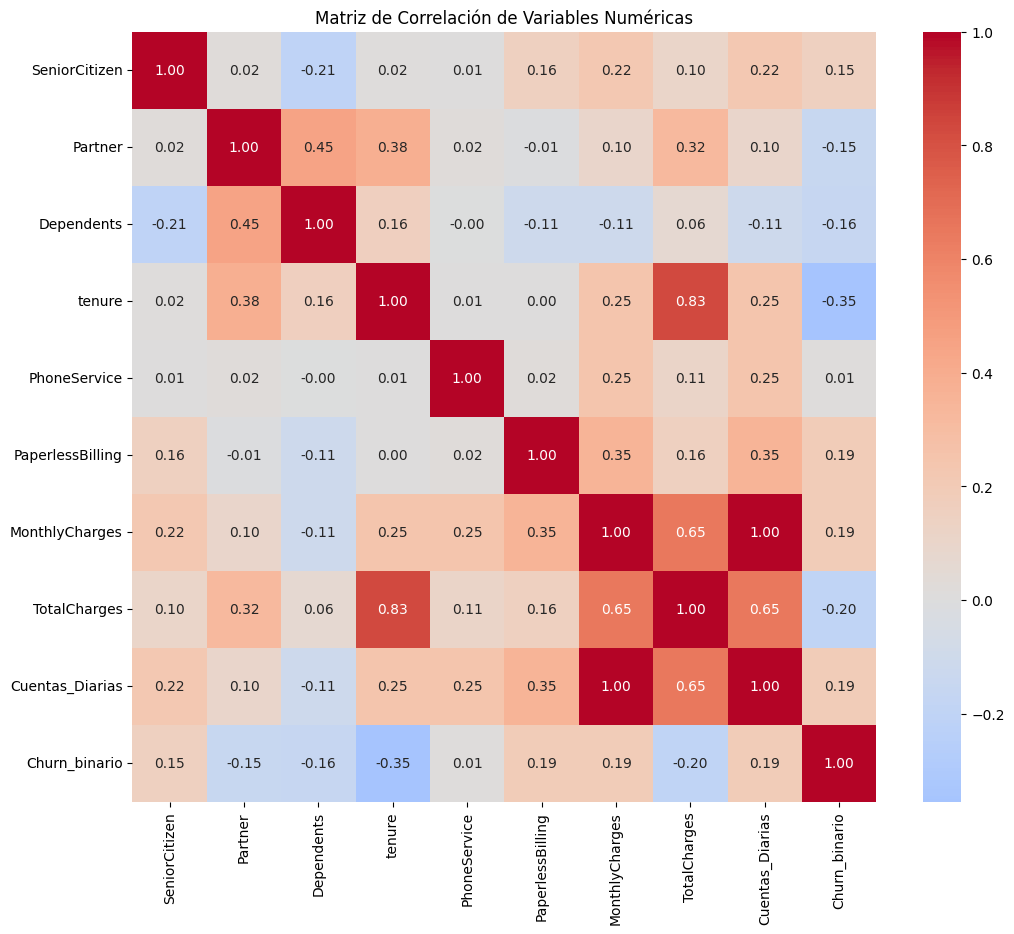

In [23]:
# Matriz de correlación

import seaborn as sns
import matplotlib.pyplot as plt

# Calcular matriz de correlación solo de variables numéricas + Churn_binario
numericas = df.select_dtypes(include=['int64', 'float64'])
corr = numericas.corr()

# Visualización
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

In [24]:
# Variables más correlacionadas con Churn
# Ordenar variables por correlación con Churn_binario
correlacion_churn = corr['Churn_binario'].sort_values(ascending=False)
print("Variables más correlacionadas con la cancelación:\n", correlacion_churn)

Variables más correlacionadas con la cancelación:
 Churn_binario       1.000000
Cuentas_Diarias     0.192914
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PhoneService        0.011691
Partner            -0.149982
Dependents         -0.163128
TotalCharges       -0.199484
tenure             -0.354049
Name: Churn_binario, dtype: float64


## **2. Análisis Dirigido**

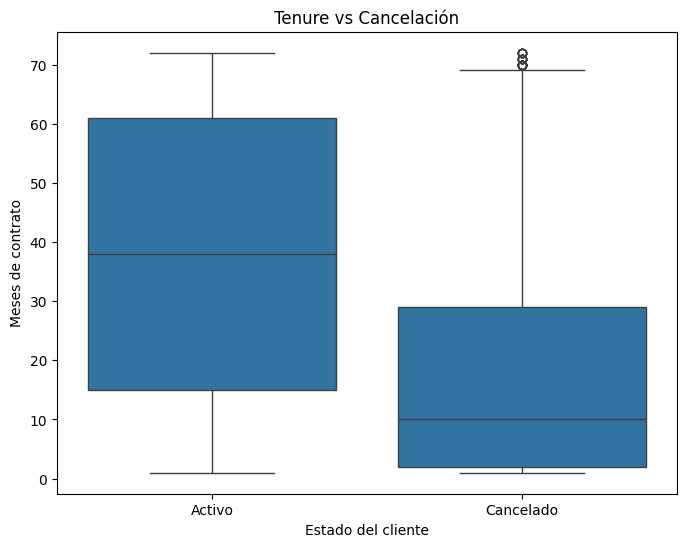

In [25]:
# Tenure vs Churn (Tiempo de contrato)
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn_binario', y='tenure', data=df)
plt.xticks([0,1], ['Activo', 'Cancelado'])
plt.title("Tenure vs Cancelación")
plt.ylabel("Meses de contrato")
plt.xlabel("Estado del cliente")
plt.show()

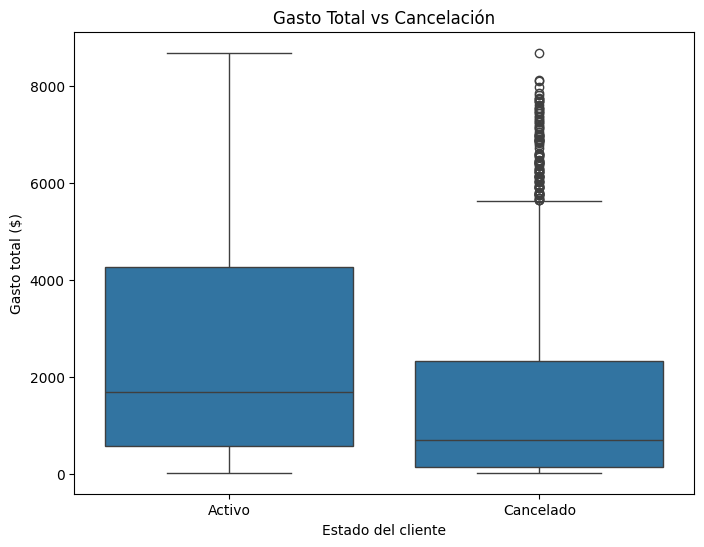

In [26]:
# TotalCharges vs Churn (Gasto total)
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn_binario', y='TotalCharges', data=df)
plt.xticks([0,1], ['Activo', 'Cancelado'])
plt.title("Gasto Total vs Cancelación")
plt.ylabel("Gasto total ($)")
plt.xlabel("Estado del cliente")
plt.show()

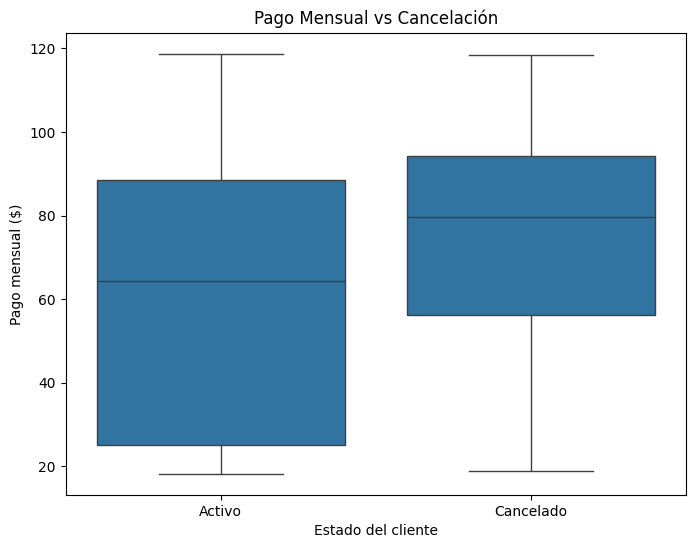

In [27]:
# MonthlyCharges vs Churn (Pago mensual)
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn_binario', y='MonthlyCharges', data=df)
plt.xticks([0,1], ['Activo', 'Cancelado'])
plt.title("Pago Mensual vs Cancelación")
plt.ylabel("Pago mensual ($)")
plt.xlabel("Estado del cliente")
plt.show()

# 🤖 Modelado Predictivo

## **1. Separación de Datos**

In [28]:
# Separar entrenamiento y prueba (70/30)
from sklearn.model_selection import train_test_split

# Ya tenemos X_encoded y y
# Dividimos el dataset original para prueba (sin SMOTE aún)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicar SMOTE solo al entrenamiento
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Escalar para modelos sensibles a la escala (Regresión Logística)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Verificar tamaños
print("Tamaño entrenamiento balanceado:", X_train_bal.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento balanceado: (7228, 24)
Tamaño prueba: (2110, 24)


## **2. Creación de Modelos**

In [29]:
# Regresión Logística
from sklearn.linear_model import LogisticRegression

# Crear modelo
lr = LogisticRegression(max_iter=1000, random_state=42)

# Entrenar con datos balanceados y estandarizados
lr.fit(X_train_bal_scaled, y_train_bal)

# Predicciones
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:,1]

In [30]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Crear modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar con datos balanceados (sin escalar)
rf.fit(X_train_bal, y_train_bal)

# Predicciones
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

## **3. Evaluación de los Modelos**

In [31]:
#Importar métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [32]:
# Función de evaluación general
def evaluar_modelo(y_test, y_pred, modelo_nombre):
    print(f"--- Evaluación: {modelo_nombre} ---")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("F1-score:", round(f1_score(y_test, y_pred), 4))
    print("\nMatriz de Confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("\nReporte completo:")
    print(classification_report(y_test, y_pred))
    print("-"*50)

In [33]:
# Evaluar Regresión Logística
evaluar_modelo(y_test, y_pred_lr, "Regresión Logística")

--- Evaluación: Regresión Logística ---
Accuracy: 0.763
Precision: 0.5471
Recall: 0.631
F1-score: 0.5861

Matriz de Confusión:
[[1256  293]
 [ 207  354]]

Reporte completo:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1549
           1       0.55      0.63      0.59       561

    accuracy                           0.76      2110
   macro avg       0.70      0.72      0.71      2110
weighted avg       0.78      0.76      0.77      2110

--------------------------------------------------


In [34]:
# Evaluar Random Forest
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

--- Evaluación: Random Forest ---
Accuracy: 0.7735
Precision: 0.5719
Recall: 0.5882
F1-score: 0.58

Matriz de Confusión:
[[1302  247]
 [ 231  330]]

Reporte completo:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1549
           1       0.57      0.59      0.58       561

    accuracy                           0.77      2110
   macro avg       0.71      0.71      0.71      2110
weighted avg       0.78      0.77      0.77      2110

--------------------------------------------------


# 📋 Interpretación y Conclusiones

## **1. Análisis de la Importancia de las Variables**

In [35]:
# Regresión Logística: Coeficientes
import pandas as pd
import numpy as np

# Obtener nombres de las columnas
columnas = X_train_bal.columns

# Coeficientes del modelo
coef = lr.coef_[0]

# Crear dataframe con variable y coeficiente
coef_df = pd.DataFrame({'Variable': columnas, 'Coeficiente': coef})
coef_df['Importancia'] = np.abs(coef_df['Coeficiente'])
coef_df = coef_df.sort_values(by='Importancia', ascending=False)

# Mostrar las 10 variables más influyentes
print("Top 10 variables más importantes en Regresión Logística:")
print(coef_df.head(10))

Top 10 variables más importantes en Regresión Logística:
                          Variable  Coeficiente  Importancia
11     InternetService_Fiber optic     2.429198     2.429198
6                   MonthlyCharges    -2.072529     2.072529
8                  Cuentas_Diarias    -2.060987     2.060987
3                           tenure    -1.851336     1.851336
12              InternetService_No    -1.248514     1.248514
7                     TotalCharges     0.927637     0.927637
17                 StreamingTV_Yes     0.824407     0.824407
18             StreamingMovies_Yes     0.793471     0.793471
22  PaymentMethod_Electronic check     0.767846     0.767846
10               MultipleLines_Yes     0.594004     0.594004


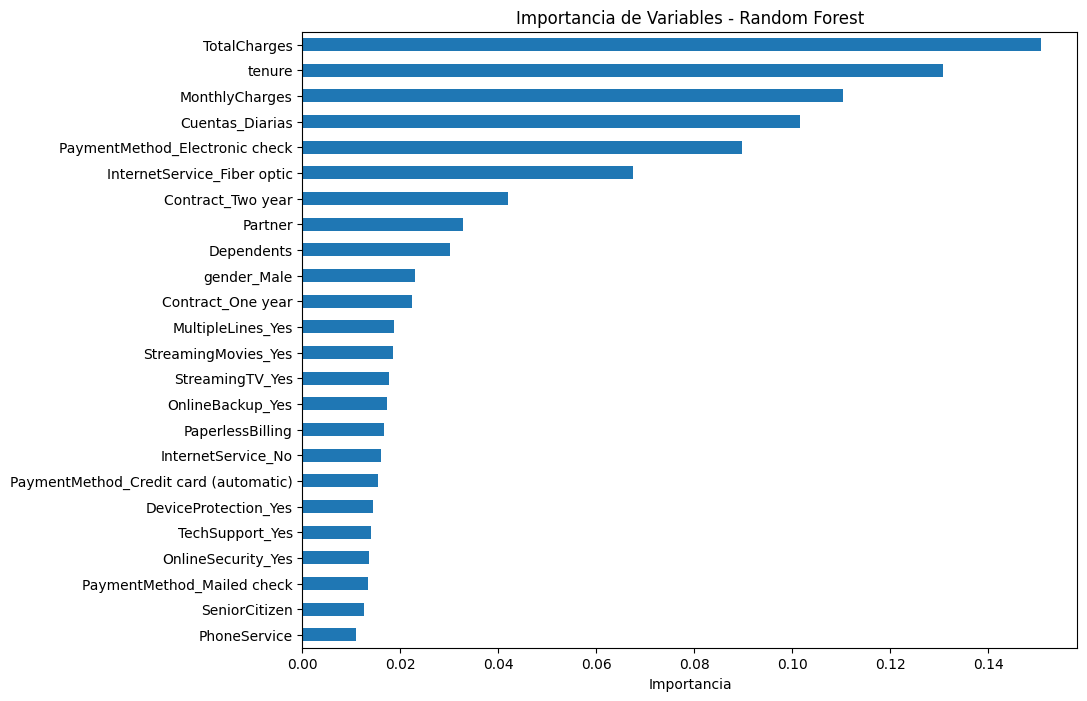

Top 10 variables más importantes en Random Forest:
TotalCharges                      0.150681
tenure                            0.130791
MonthlyCharges                    0.110419
Cuentas_Diarias                   0.101632
PaymentMethod_Electronic check    0.089731
InternetService_Fiber optic       0.067399
Contract_Two year                 0.042039
Partner                           0.032756
Dependents                        0.030027
gender_Male                       0.022982
dtype: float64


In [36]:
# Random Forest: Importancia de variables
import matplotlib.pyplot as plt

# Importancia de variables
importancias = rf.feature_importances_
feat_importances = pd.Series(importancias, index=X_train_bal.columns)
feat_importances = feat_importances.sort_values(ascending=True)

# Gráfico horizontal
plt.figure(figsize=(10,8))
feat_importances.plot(kind='barh')
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")
plt.show()

# Mostrar top 10
print("Top 10 variables más importantes en Random Forest:")
print(feat_importances.sort_values(ascending=False).head(10))

## **2. Conclusión**

# 📊 Informe de Predicción de Cancelación – Telecom X

## 1️⃣ Objetivo del Proyecto
Predecir qué clientes tienen mayor probabilidad de cancelar sus servicios (**churn**) para implementar estrategias de retención proactivas y reducir pérdidas.

---

## 2️⃣ Preprocesamiento de Datos
- Carga del dataset limpio (`TelecomX_LATAM.csv`) con 7032 registros y 23 columnas.
- Eliminación de columnas irrelevantes: `customerID`.
- Codificación de variables categóricas mediante **One-Hot Encoding**.
- Balanceo de la clase minoritaria con **SMOTE**.
- Estandarización de variables numéricas para **Regresión Logística**.

---

## 3️⃣ Análisis Exploratorio y Correlación
Variables más correlacionadas con **churn**:

| Variable            | Correlación |
|--------------------|------------|
| tenure             | -0.354     |
| TotalCharges       | -0.199     |
| Cuentas_Diarias    | 0.193      |
| MonthlyCharges     | 0.193      |
| PaperlessBilling   | 0.191      |

**Insights gráficos:**
- Menor tenure → mayor churn.
- Pagos mensuales altos → mayor churn.
- Gasto total bajo → mayor churn.

---

## 4️⃣ Modelado Predictivo
Se entrenaron dos modelos:

### Regresión Logística
- Datos balanceados y estandarizados.
- Métricas:
  - Accuracy: 0.763
  - Recall (Churn): 0.631
  - F1-score: 0.586
- Detecta mejor clientes en riesgo (mayor recall).

### Random Forest
- Datos balanceados, no requiere escalado.
- Métricas:
  - Accuracy: 0.773
  - Recall (Churn): 0.588
  - F1-score: 0.58
- Captura relaciones no lineales, mayor precisión general.

---

## 5️⃣ Importancia de Variables

### Regresión Logística – Top 5
| Variable                     | Coeficiente | Interpretación |
|-------------------------------|------------|----------------|
| InternetService_Fiber optic   | 2.429      | Mayor riesgo de churn |
| MonthlyCharges                | -2.073     | Pagos mensuales altos → más churn |
| Cuentas_Diarias               | -2.061     | Mayor actividad diaria → menos churn |
| tenure                        | -1.851     | Contratos largos → menor churn |
| InternetService_No            | -1.249     | Sin internet → menor riesgo |

### Random Forest – Top 5
| Variable                     | Importancia | Interpretación |
|-------------------------------|------------|----------------|
| TotalCharges                  | 0.151      | Menor gasto total → mayor churn |
| tenure                        | 0.131      | Contratos cortos → mayor churn |
| MonthlyCharges                | 0.110      | Pagos altos → mayor churn |
| Cuentas_Diarias               | 0.102      | Mayor actividad diaria → menor churn |
| PaymentMethod_Electronic check| 0.090      | Pago con cheque electrónico → mayor riesgo |

**Conclusión:** Variables consistentes en ambos modelos: `tenure`, `TotalCharges`, `MonthlyCharges`, `Cuentas_Diarias`.

---

## 6️⃣ Estrategias de Retención
1. **Clientes nuevos / tenure bajo:** promociones, descuentos por renovación temprana.
2. **Pagos mensuales altos / pago electrónico:** planes flexibles, incentivos.
3. **Bajo gasto total:** bundles, servicios adicionales para engagement.
4. **Clientes con fibra óptica:** soporte técnico proactivo y atención personalizada.

---

## 7️⃣ Conclusión Final
- La predicción de churn permite anticipar clientes en riesgo y diseñar campañas efectivas.
- Regresión Logística y Random Forest ofrecen insights complementarios: interpretabilidad vs precisión.
- Variables clave: `tenure`, `TotalCharges`, `MonthlyCharges`, `Cuentas_Diarias`, `InternetService`.
- Priorizar clientes jóvenes, de alto gasto o bajo engagement para reducir la tasa de cancelación.